In [1]:
# Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Criando os Dados (Horas Estudadas vs. Aprovação)
Aqui definimos o que a máquina vai observar. X são as horas de estudo (causa) e y é o resultado (efeito: 0 para reprovado, 1 para aprovado). Notem que os dados são 'sujos': o aluno que estudou 5 horas passou, mas o de 6 horas reprovou. Isso torna o desafio real para a IA.

In [2]:
# X = Variável independente (Feature: Horas)
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])

In [3]:
# y = Variável dependente (Target: 0 = Reprovou, 1 = Passou)
y = np.array([0, 0, 0, 0, 1, 0, 1, 1, 1, 1])

# Dividindo os dados em Treino e Teste
Separamos 80% dos dados para o treino (estudo) e 20% para o teste (a prova final). O random_state=42 serve apenas para que o sorteio dos dados seja sempre o mesmo toda vez que rodarmos o código.

In [4]:
# Vamos usar 80% dos dados para ensinar o modelo e 20% para testar se ele aprendeu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializando e Treinando o Modelo
O comando .fit() é o momento em que a IA analisa os dados de treino e tenta encontrar a Função Sigmóide que melhor separa os aprovados dos reprovados.

In [5]:
modelo = LogisticRegression()
modelo.fit(X_train, y_train) # O 'fit' é onde a mágica matemática acontece

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Fazendo Previsões

In [6]:
# Pedimos ao modelo para prever os resultados dos 20% de dados que ele não viu
previsoes = modelo.predict(X_test)

In [7]:
# Aqui vemos a probabilidade exata (a saída da Função Sigmóide antes do arredondamento)
probabilidades = modelo.predict_proba(X_test)

Avaliando a Performance do Modelo

In [8]:
print("--- Resultados do Modelo ---")
print(f"Acurácia: {accuracy_score(y_test, previsoes) * 100}%\n")

print("Matriz de Confusão:")
print(confusion_matrix(y_test, previsoes))

print("\nProbabilidades Calculadas (0, 1):")
print(np.round(probabilidades, 2))

--- Resultados do Modelo ---
Acurácia: 100.0%

Matriz de Confusão:
[[1 0]
 [0 1]]

Probabilidades Calculadas (0, 1):
[[0.05 0.95]
 [0.95 0.05]]


# Criação do modelo SVM
Enquanto a Logística usa uma curva de probabilidade, o SVM tenta traçar uma linha (muro) que mantenha a maior distância possível entre os grupos. O kernel='linear' diz que queremos uma linha reta.

In [9]:
# Modelo B: SVM (Linear)
modelo_svm = SVC(kernel='linear', probability=True)
modelo_svm.fit(X, y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# Função
Transforma os cálculos invisíveis da Regressão Logística e do SVM em um gráfico comparativo.

In [10]:
def mostrar_grafico_comparativo(X, y, mod_log, mod_svm):
    plt.figure(figsize=(10, 6))
    
    # Pontos reais
    plt.scatter(X, y, color='black', zorder=5, label='Dados Reais')
    
    # Criando linha de horas para a curva (0 a 11)
    X_plot = np.linspace(0, 11, 300).reshape(-1, 1)
    
    # Curva da Regressão Logística (Probabilidades)
    prob_log = mod_log.predict_proba(X_plot)[:, 1]
    plt.plot(X_plot, prob_log, color='red', label='Regressão Logística (Curva)', linewidth=2)
    
    # Fronteira do SVM
    # No SVM 1D, a fronteira é o ponto onde a previsão muda
    decisao_svm = mod_svm.predict(X_plot)
    # Vamos achar onde o SVM muda de 0 para 1
    fronteira_svm = X_plot[np.diff(decisao_svm, prepend=decisao_svm[0]) != 0]
    
    if len(fronteira_svm) > 0:
        plt.axvline(x=fronteira_svm[0], color='blue', linestyle='--', label='Fronteira SVM', linewidth=2)

    # Configurações do Gráfico
    plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
    plt.title('Comparação: Regressão Logística vs SVM')
    plt.xlabel('Horas Estudadas')
    plt.ylabel('Probabilidade / Classe')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# O modelo SVM
A curva vermelha mostra a Logística mudando de opinião gradualmente. A linha azul mostra onde o SVM 'cortou' o grupo ao meio. É a prova visual de que algoritmos diferentes resolvem o mesmo problema de formas diferentes.


Aprovação em uma Prova.

Eixo X: Horas estudadas (Variável Independente).

Eixo Y: Probabilidade de passar na prova (0 a 1).

Pontos no gráfico: Representam alunos reais. 


Os alunos que reprovaram estão na linha do y=0 e os que passaram estão na linha do y=1.

--- Comparação Finalizada ---
Fronteira de decisão encontrada pelo SVM: [1]


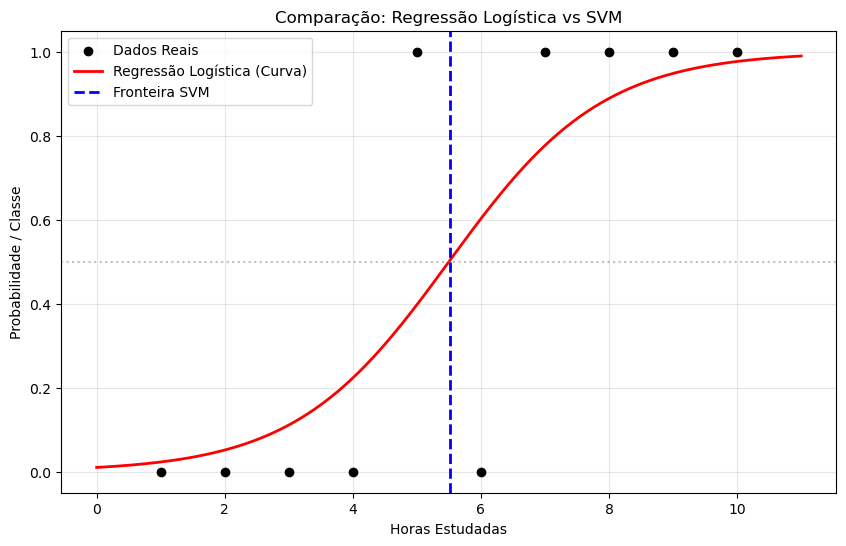

In [11]:
# Chamando a função para mostrar o gráfico
print("--- Comparação Finalizada ---")
print(f"Fronteira de decisão encontrada pelo SVM: {modelo_svm.predict([[5.5]])}") # Teste rápido
mostrar_grafico_comparativo(X, y, modelo, modelo_svm)